In [1]:
import warnings

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

from tensorflow import keras
from keras import optimizers, initializers

from tensorflow.keras.callbacks import Callback
from tqdm.keras import TqdmCallback
from tqdm import tqdm

from scipy.stats import norm

import modelnn as thf

2026-03-02 17:36:58.580149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772483818.597756   76976 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772483818.602986   76976 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772483818.617613   76976 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772483818.617641   76976 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772483818.617644   76976 computation_placer.cc:177] computation placer alr

# General framework

Let us consider that for a given statistical model, we can segment the vector of parameters, $\boldsymbol \theta$ into two major sets of parameters:
* $\boldsymbol{\phi}$: Parameters that can be modeled as outputs to a neural network;
* $\boldsymbol{\psi}$: Global parameters modeled as constants for the entire population;

# Linear regression variations

### $\phi = \emptyset, \psi = \{\mu, \sigma^2\}$

Sample mean: 4.940510915210578
Sample variance: 0.983836917453983


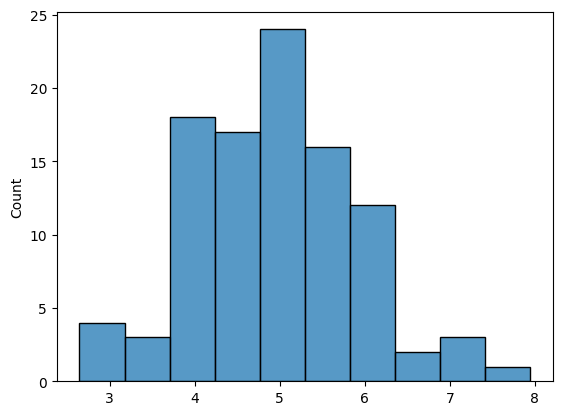

In [2]:
n = 100

mu_0 = 5
sigma2_0 = 1

y0 = np.random.normal(loc = mu_0, scale = np.sqrt(sigma2_0), size = n)

print("Sample mean: {}".format(np.mean(y0)))
print("Sample variance: {}".format(np.var(y0, ddof = 1)))

sns.histplot(x = y0)
plt.show()

In [3]:
regression0_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y0)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y0)}
}

def regression0_loglikelihood_loss(model, nn_output, data):
    X, y = data

    mu = model.get_variable("mu")
    sigma2 = model.get_variable("sigma2")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    
    return -loglik

In [4]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression0_model = thf.ModelNN(regression0_parameters, regression0_loglikelihood_loss,
                                    None, None, None,
                                    input_dim = (None, 1), seed = 10)
    
    data0 = [y0]
    
    regression0_mu_before_pretrain = regression0_model.predict("mu")
    regression0_sigma2_before_pretrain = regression0_model.predict("sigma2")
    
    regression0_model.train_model(None, data0,
                                  epochs = 5000, shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-9, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-6, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                  deterministic = True,
                                  verbose = 1)
    
    regression0_mu_after_train = regression0_model.predict("mu")
    regression0_sigma2_after_train = regression0_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 300 / 5000 ]  | Loss:  0 | Param Dist:  2.68923186e-14 | Independent Learning rate:  0.01 | Network Learning rate:  0.01 | Speed:  5644  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 3.870 seconds.


In [5]:
df_summary0 = regression0_model.summary()
df_summary0

,index,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,4.945486,0.098449,4.752529,5.138443,0.969178,0.136725,0.701203,1.237153


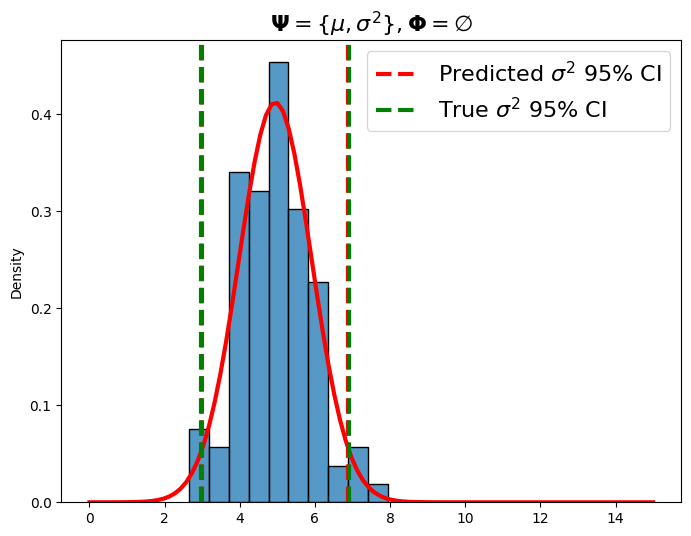

In [6]:
xs = np.linspace(0, 15, 100)

alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var0 = df_summary0["mu_se"]**2 + df_summary0["sigma2"]
y_new_lower0 = df_summary0["mu"] - z_norm * np.sqrt(y_new_var0)
y_new_upper0 = df_summary0["mu"] + z_norm * np.sqrt(y_new_var0)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = y0, stat = "density", ax = ax)
sns.lineplot(x = xs, y = norm.pdf(xs, loc = regression0_mu_after_train, scale = regression0_sigma2_after_train), color = "red", linewidth = 3, ax = ax)
ax.axvline(y_new_lower0[0], color = "red", linewidth = 3, linestyle = "dashed", label = r"Predicted $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0[0], color = "red", linewidth = 3, linestyle = "dashed")

sort_sigma2_0 = sigma2_0
y_new_lower0_true = df_summary0["mu"] - z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )
y_new_upper0_true = df_summary0["mu"] + z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )

ax.axvline(y_new_lower0_true[0], color = "green", linewidth = 3, linestyle = "dashed", label = r"True $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0_true[0], color = "green", linewidth = 3, linestyle = "dashed")
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu, \sigma^2\}, \boldsymbol{\Phi} = \emptyset$", fontsize = 16)

plt.show()

### $\phi = \{\mu\}, \psi = \{\sigma^2\}$

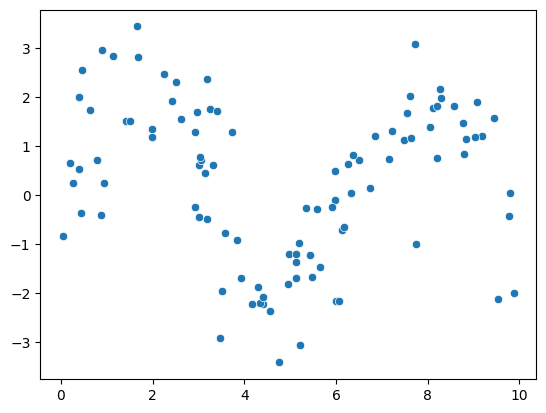

In [7]:
n = 100

sigma2_1 = 1

np.random.seed(10)
x1 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_f1 = lambda x : 2*np.sin(x)
y1 = true_f1(x1) + np.random.normal(loc = 0.0, scale = np.sqrt(sigma2_1), size = n)

sns.scatterplot(x = x1, y = y1)
plt.show()

In [31]:
?thf.ModelNN.__init__

Signature:
thf.ModelNN.__init__(
    self,
    parameters,
    loglikelihood_loss,
    neural_network_structure=None,
    neural_network_call=None,
    neural_network_call_nolast=None,
    input_dim=None,
    seed=None,
)
Docstring: Initialize self.  See help(type(self)) for accurate signature.
File:      ~/codes/thesis_frailty/modelnn.py
Type:      function

In [8]:
regression1_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y1)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y1)}
}

def regression1_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2")
    # Simply replaces the linear predictor by the nn_output
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression1_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression1_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression1_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [9]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    data1 = [y1]
    
    sort_x1 = np.sort(x1)
    regression1_mu_before_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_before_pretrain = regression1_model.predict("sigma2")
    
    regression1_model.pre_train_model(x1, data1,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression1_mu_after_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_pretrain = regression1_model.predict("sigma2")

In [10]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    regression1_model.train_model(x1, data1,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  verbose = 1, print_freq = 100)
    
    regression1_mu_after_train = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_train = regression1_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 11200 / 15000 ]  | Loss:  164.91272 | Param Dist:  3.86396522e-07 | Independent Learning rate:  3.90625e-05 | Network Learning rate:  3.90625e-05 | Speed:  3038  it/s    
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 100 / 15000 ]  | Loss:  165.150497 | Param Dist:  5.49624701e-07 | Independent Learning rate:  3.90625e-05 | Network Learning rate:  3.90625e-05 | Speed:  3048  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 5.080 seconds.


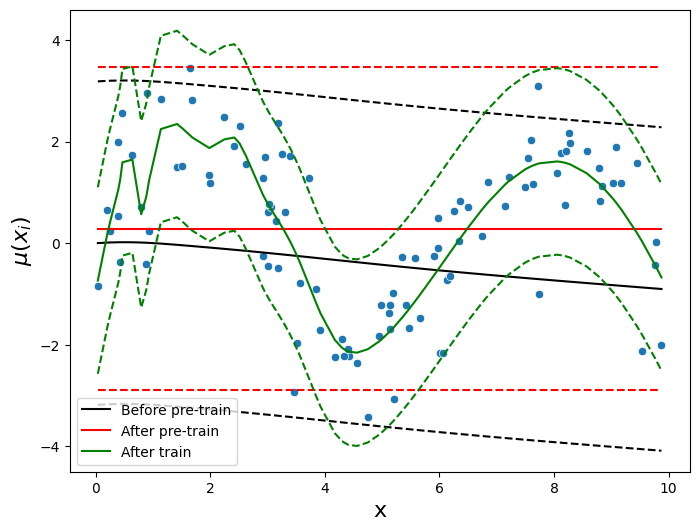

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)

sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain - 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain + 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain - 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain + 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train - 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train + 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [12]:
sort_x1 = np.sort(x1)

df_summary1 = regression1_model.summary(sort_x1[:,None])
df_summary1.insert(1, "x", sort_x1)
df_summary1

,index,x,sigma2,sigma2_se,sigma2_lower,sigma2_upper,mu,mu_se,mu_lower,mu_upper
0,1,0.039483,0.842959,0.119324,0.609089,1.076829,-0.733842,1.187976,-3.062232,1.594547
1,2,0.207519,0.842959,0.119324,0.609089,1.076829,0.197463,1.584411,-2.907925,3.302851
2,3,0.253998,0.842959,0.119324,0.609089,1.076829,0.419824,1.696710,-2.905667,3.745315
3,4,0.392818,0.842959,0.119324,0.609089,1.076829,1.040625,2.018984,-2.916511,4.997760
4,5,0.399592,0.842959,0.119324,0.609089,1.076829,1.074895,2.032638,-2.909003,5.058793
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,0.842959,0.119324,0.609089,1.076829,0.213706,2.679414,-5.037848,5.465261
96,97,9.533933,0.842959,0.119324,0.609089,1.076829,0.042211,2.700776,-5.251213,5.335635
97,98,9.770807,0.842959,0.119324,0.609089,1.076829,-0.440434,2.756489,-5.843052,4.962184
98,99,9.788191,0.842959,0.119324,0.609089,1.076829,-0.477904,2.760594,-5.888568,4.932760


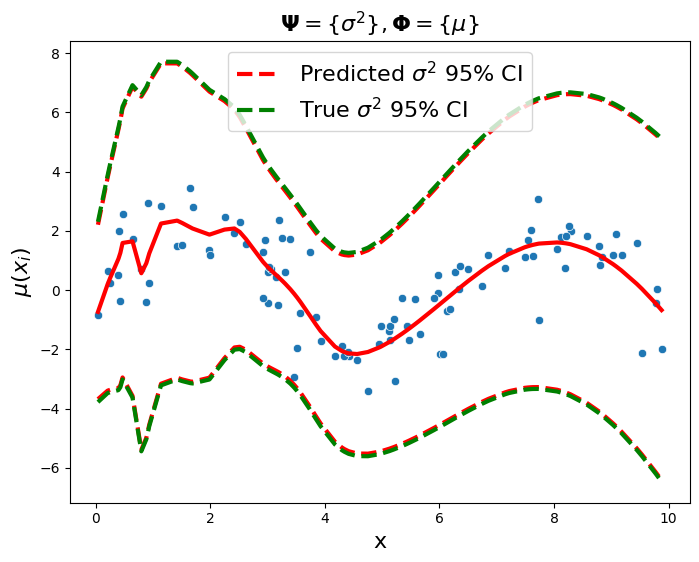

In [13]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var1 = df_summary1["mu_se"]**2 + df_summary1["sigma2"]
y_new_lower1 = df_summary1["mu"] - z_norm * np.sqrt(y_new_var1)
y_new_upper1 = df_summary1["mu"] + z_norm * np.sqrt(y_new_var1)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)
sns.lineplot(x = sort_x1, y = df_summary1["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x1, y = y_new_lower1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_1 = sigma2_1
y_new_lower1_true = df_summary1["mu"] - z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )
y_new_upper1_true = df_summary1["mu"] + z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )

# sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "purple", linestyle = "dashed", ax = ax)
# sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "purple", linestyle = "dashed", ax = ax)
sns.lineplot(x = sort_x1, y = y_new_lower1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\sigma^2\}, \boldsymbol{\Phi} = \{\mu\}$", fontsize = 16)

plt.show()

Just to exemplify the method variable_function_covariance as a general way of obtaining the covariance structure of any function of the parameters, we consider the transformation
\begin{equation*}
f(\mu, \sigma^2) = [\mu, 2\sigma^2]
\end{equation*}
Of course, we expect to see a $2 \times 2$ covariance matrix whose diagonal is equivalent to $\text{Var}[\widehat{\mu}]$ and $4\text{Var}[\widehat{\sigma}^2]$.

In [14]:
def fun(model, nn_output, data):
    X, y = data
    mu = model.get_variable("mu", nn_output)
    sigma2 = model.get_variable("sigma2")
    return tf.concat([mu, 2*tf.tile(sigma2[:,None], (tf.size(mu), 1))], axis = -1)

fun_cov = regression1_model.variable_function_covariance(fun, sort_x1[:5], data1)
fun_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[1.4112856 , 0.01155346],
        [0.01155338, 0.05695252]],

       [[2.510357  , 0.01569607],
        [0.01569596, 0.05695252]],

       [[2.8788254 , 0.01685217],
        [0.01685204, 0.05695252]],

       [[4.076296  , 0.02014508],
        [0.02014492, 0.05695252]],

       [[4.131619  , 0.02028302],
        [0.02028286, 0.05695252]]], dtype=float32)>

In [15]:
theta_cov = regression1_model.covariance_output(sort_x1[:5])
theta_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[0.01423813, 0.00577669],
        [0.00577673, 1.4112856 ]],

       [[0.01423813, 0.00784798],
        [0.00784804, 2.510357  ]],

       [[0.01423813, 0.00842602],
        [0.00842608, 2.8788254 ]],

       [[0.01423813, 0.01007246],
        [0.01007254, 4.076296  ]],

       [[0.01423813, 0.01014143],
        [0.01014151, 4.131619  ]]], dtype=float32)>

In [16]:
theta_cov[:,0,0]*4

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.05695252, 0.05695252, 0.05695252, 0.05695252, 0.05695252],
      dtype=float32)>

Indeed, we can see that the variances match exactly to their expected values.

### $\phi = \{\sigma^2\}, \psi = \{\mu\}$

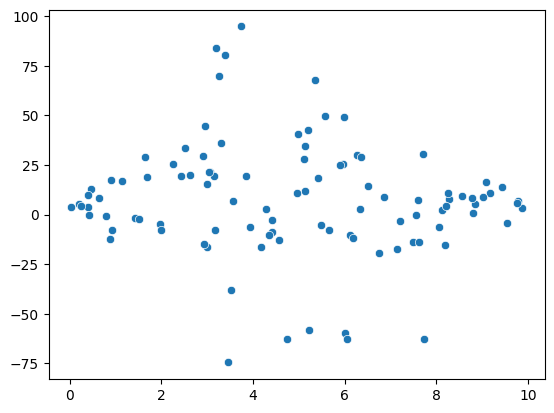

In [17]:
n = 100

mu = 5

np.random.seed(10)
x2 = np.random.uniform(low = 0.0, high = 10.0, size = n)

# true_f = lambda x : 1000 * 1/np.sqrt(2*np.pi*x) * np.exp(-(x-5)**2/(2*2))
def true_sigma2_2(x):
    y = np.zeros_like(x)
    y0 = 50
    y[x <= 5] = y0/5 * x[x <= 5]
    y[x > 5] = -y0/5 * x[x > 5] + 2*y0
    return 1+y**2

sigma2_2 = true_sigma2_2(x2)

y2 = mu + np.random.normal(loc = 0, scale = np.sqrt(sigma2_2))

sns.scatterplot(x = x2, y = y2)
plt.show()

In [18]:
regression2_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y2)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1500.0}
}

def regression2_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression2_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression2_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression2_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [19]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression2_model = thf.ModelNN(regression2_parameters, regression2_loglikelihood_loss,
                                      regression2_neural_network, regression2_network_call,
                                      regression2_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data2 = [y2]
    sort_x2 = np.sort(x2)
    
    regression2_mu_before_pretrain = regression2_model.predict("mu")
    regression2_sigma2_before_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()
    
    regression2_model.pre_train_model(x2, data2,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression2_mu_after_pretrain = regression2_model.predict("mu")
    regression2_sigma2_after_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

In [20]:
with tf.device("/CPU:0"):
    regression2_model.train_model(x2, data2,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  deterministic = True,
                                  verbose = 1, print_freq = 100)
    
    regression2_mu_after_train = regression2_model.predict("mu")
    regression2_sigma2_after_train = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 7000 / 15000 ]  | Loss:  546.057617 | Param Dist:  1.07763492e-06 | Independent Learning rate:  0.0003125 | Network Learning rate:  0.0003125 | Speed:  2952  it/s   
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 100 / 15000 ]  | Loss:  535.2276 | Param Dist:  6.78971787e-07 | Independent Learning rate:  0.0003125 | Network Learning rate:  0.0003125 | Speed:  3114  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 3.664 seconds.


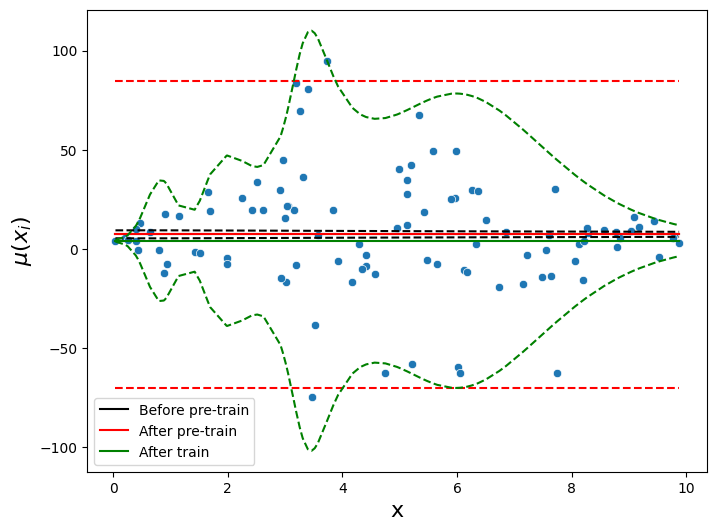

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ), ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ), ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ), ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [22]:
df_summary2 = regression2_model.summary(sort_x2[:,None])
df_summary2.insert(1, "x", sort_x2)
df_summary2

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,4.150097,0.219996,3.718913,4.581282,0.049257,0.208497,-0.359390,0.457905
1,2,0.207519,4.150097,0.219996,3.718913,4.581282,0.946709,4.050317,-6.991766,8.885184
2,3,0.253998,4.150097,0.219996,3.718913,4.581282,1.972491,8.437213,-14.564143,18.509127
3,4,0.392818,4.150097,0.219996,3.718913,4.581282,13.616177,57.641907,-99.359894,126.592239
4,5,0.399592,4.150097,0.219996,3.718913,4.581282,14.800503,62.598236,-107.889786,137.490799
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,4.150097,0.219996,3.718913,4.581282,31.399475,24.596754,-16.809277,79.608231
96,97,9.533933,4.150097,0.219996,3.718913,4.581282,26.952278,21.543333,-15.271881,69.176437
97,98,9.770807,4.150097,0.219996,3.718913,4.581282,18.125948,15.237829,-11.739649,47.991547
98,99,9.788191,4.150097,0.219996,3.718913,4.581282,17.605759,14.853838,-11.507229,46.718746


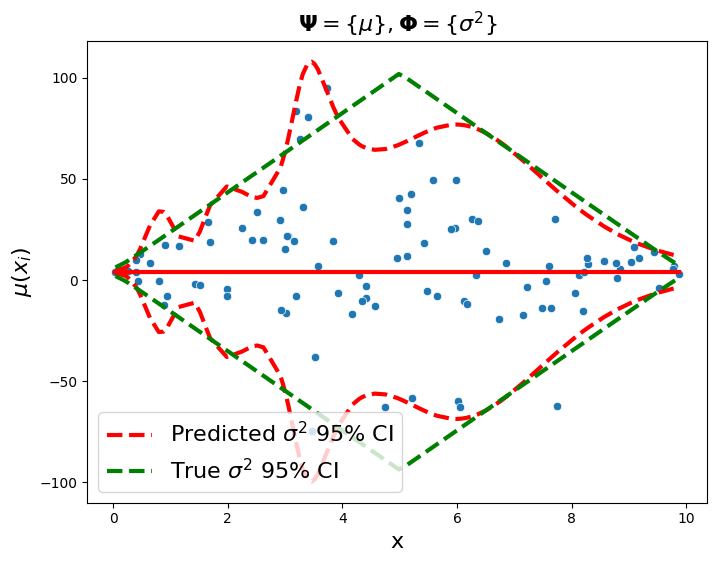

In [23]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var = df_summary2["mu_se"]**2 + df_summary2["sigma2"]
y_new_lower = df_summary2["mu"] - z_norm * np.sqrt(y_new_var)
y_new_upper = df_summary2["mu"] + z_norm * np.sqrt(y_new_var)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)
sns.lineplot(x = sort_x2, y = df_summary2["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x2, y = y_new_lower, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_2 = true_sigma2_2(sort_x2)
y_new_lower2_true = df_summary2["mu"] - z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )
y_new_upper2_true = df_summary2["mu"] + z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )

sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu\}, \boldsymbol{\Phi} = \{\sigma^2\}$", fontsize = 16)

plt.show()

### $\phi = \{\mu, \sigma^2\}, \psi = \emptyset$

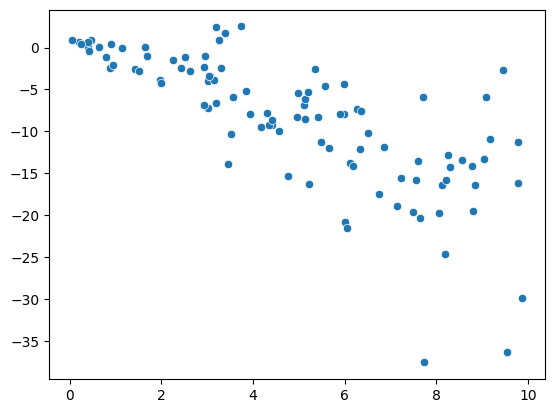

In [24]:
n = 100

np.random.seed(10)
x3 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_mu_3 = lambda x : -2*x + 1
true_sigma2_3 = lambda x : x**2

mu_3 = true_mu_3(x3)
sigma2_3 = true_sigma2_3(x3)

y3 = mu_3 + np.random.normal(loc = 0, scale = np.sqrt(sigma2_3))

sns.scatterplot(x = x3, y = y3)
plt.show()

In [25]:
regression3_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y3)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": np.var(y3)}
}

def regression3_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )

    return -loglik

def regression3_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    # model.dense3 = keras.layers.Dense(units = 2, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False, name = "output")
    model.dense3 = keras.layers.Dense(units = 2, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression3_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression3_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [26]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression3_model = thf.ModelNN(regression3_parameters, regression3_loglikelihood_loss,
                                    regression3_neural_network, regression3_network_call,
                                    regression3_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data3 = [y3]
    sort_x3 = np.sort(x3)
    
    regression3_mu_before_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_before_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()
    
    regression3_model.pre_train_model(x3, data3,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression3_mu_after_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

In [27]:
with tf.device("/CPU:0"):
    regression3_model.train_model(x3, data3,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-6, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  deterministic = True,
                                  verbose = 1, print_freq = 100)
    
    regression3_mu_after_train = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_train = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 8400 / 15000 ]  | Loss:  4215.47754 | Param Dist:  1.65003416e-06 | Independent Learning rate:  0.01 | Network Learning rate:  0.00015625 | Speed:  2901  it/s   
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 800 / 15000 ]  | Loss:  4228.1665 | Param Dist:  1.01534465e-06 | Independent Learning rate:  0.01 | Network Learning rate:  0.00015625 | Speed:  2808  it/s    
Done.
Extracting covariance structure.
Done.
Optimization finished in 4.527 seconds.


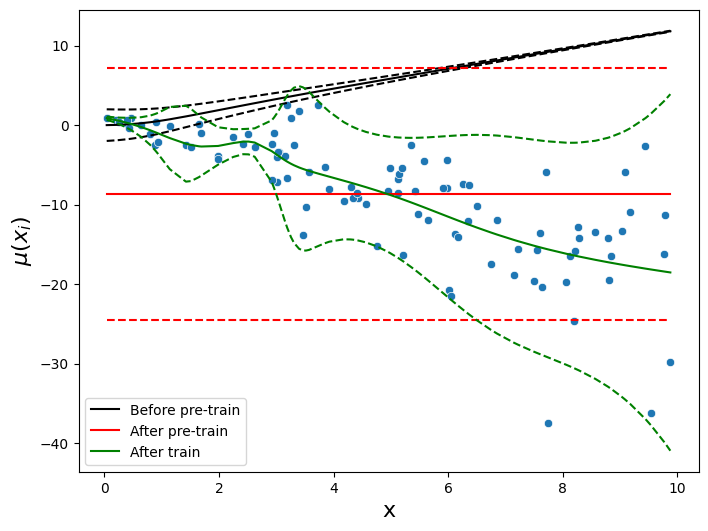

In [28]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)

sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain - 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain + 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain - 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain + 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train - 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train + 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [29]:
df_summary3 = regression3_model.summary(sort_x3[:,None])
df_summary3.insert(1, "x", sort_x3)
df_summary3

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,0.875765,0.348491,0.192736,1.558794,0.010054,0.007662,-0.004962,0.025071
1,2,0.207519,0.627063,0.269716,0.098429,1.155696,0.028861,0.017344,-0.005132,0.062854
2,3,0.253998,0.547204,0.247680,0.061761,1.032647,0.040443,0.022300,-0.003264,0.084151
3,4,0.392818,0.293415,0.197163,-0.093017,0.679848,0.100101,0.042523,0.016758,0.183444
4,5,0.399592,0.280384,0.195284,-0.102366,0.663134,0.104204,0.043711,0.018533,0.189876
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,-18.051794,3.015988,-23.963022,-12.140566,89.665634,117.810913,-141.239517,320.570801
96,97,9.533933,-18.155832,3.054192,-24.141937,-12.169726,95.805603,126.837975,-152.792267,344.403473
97,98,9.770807,-18.418623,3.152622,-24.597649,-12.239597,115.247360,155.617538,-189.757431,420.252136
98,99,9.788191,-18.437550,3.159814,-24.630672,-12.244427,116.899597,158.078278,-192.928131,426.727325


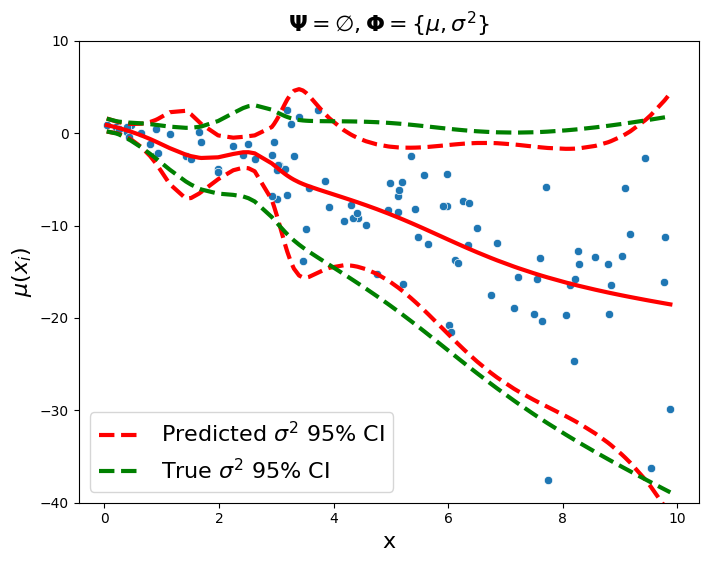

In [30]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var3 = df_summary3["mu_se"]**2 + df_summary3["sigma2"]
y_new_lower3 = df_summary3["mu"] - z_norm * np.sqrt(y_new_var3)
y_new_upper3 = df_summary3["mu"] + z_norm * np.sqrt(y_new_var3)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)
sns.lineplot(x = sort_x3, y = df_summary3["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x3, y = y_new_lower3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x3, y = y_new_upper3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_3 = true_sigma2_3(sort_x2)
y_new_lower3_true = df_summary3["mu"] - z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )
y_new_upper3_true = df_summary3["mu"] + z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )

sns.lineplot(x = sort_x2, y = y_new_lower3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.set_ylim(-40,10)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \emptyset, \boldsymbol{\Phi} = \{\mu, \sigma^2\}$", fontsize = 16)

plt.show()